# 🎯 Prior-Enhanced UNet - Few-Shot Learning
Simplified, working implementation with visible predictions

In [1]:
import numpy as np
import torch
import torch.nn as nn
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

✅ All imports successful
Using device: cpu


In [2]:
# Load images
print("Loading data...")
image_dir = Path('train-images')
available_images = sorted([int(p.stem) for p in image_dir.glob('*.png')])

images_list = []
for idx in tqdm(available_images, desc='Images'):
    img = cv2.imread(str(image_dir / f'{idx}.png'), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        images_list.append((img / 255.0).astype(np.float32))

images_np = np.array(images_list)

# Load labels
labels_df = pd.read_csv('y_train.csv', index_col=0).T
labels_2d = labels_df.iloc[:len(images_np)].values.reshape(-1, 256, 256)

print(f"Images: {images_np.shape}")
print(f"Labels: {labels_2d.shape}")
print(f"Classes: {len(np.unique(labels_2d))}")

Loading data...


Images: 100%|██████████| 1358/1358 [00:02<00:00, 480.94it/s]


Images: (1358, 256, 256)
Labels: (1358, 256, 256)
Classes: 55


In [3]:
# Check actual number of classes
print(f"\n📊 Class Analysis:")
unique_classes = np.unique(labels_2d)
print(f"Unique classes in data: {len(unique_classes)}")
print(f"Class range: {unique_classes.min()} to {unique_classes.max()}")
print(f"Classes: {sorted(unique_classes)[:20]}...")  # Show first 20

# Class distribution
class_dist = np.bincount(labels_2d.flatten())
print(f"\nClass frequency distribution:")
for cls_id, count in enumerate(class_dist):
    if count > 0:
        pct = 100 * count / labels_2d.size
        print(f"  Class {cls_id}: {count:6d} pixels ({pct:5.2f}%)")


📊 Class Analysis:
Unique classes in data: 55
Class range: 0 to 54
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]...

Class frequency distribution:
  Class 0: 83046868 pixels (93.31%)
  Class 1:    926 pixels ( 0.00%)
  Class 2:    673 pixels ( 0.00%)
  Class 3: 115092 pixels ( 0.13%)
  Class 4: 208579 pixels ( 0.23%)
  Class 5: 201305 pixels ( 0.23%)
  Class 6: 283963 pixels ( 0.32%)
  Class 7:   4723 pixels ( 0.01%)
  Class 8:   4422 pixels ( 0.00%)
  Class 9: 247582 pixels ( 0.28%)
  Class 10:  19671 pixels ( 0.02%)
  Class 11:  17542 pixels ( 0.02%)
  Class 12: 320273 pixels ( 0.36%)
  Class 13:   7937 pixels ( 0.01%)
  Class 14:   6131 pixels ( 0.01%)
  Class 15:   7501 pixels ( 0.01%)
  Class 16:  65158 pixels ( 0.07%)
  Class 17:  55008 pixels ( 0.06

In [4]:
# Enhanced Prior generator with multi-scale features
class PriorGenerator:
    @staticmethod
    def get_prior(image):
        """Create multi-scale priors: intensity + edges + texture"""
        # Normalize
        img_norm = image / (image.max() + 1e-8)
        
        # Sobel edges (multi-scale)
        sx = cv2.Sobel(img_norm, cv2.CV_32F, 1, 0, ksize=3)
        sy = cv2.Sobel(img_norm, cv2.CV_32F, 0, 1, ksize=3)
        edges = np.sqrt(sx**2 + sy**2)
        edges = edges / (edges.max() + 1e-8)
        
        # Laplacian (texture/corners)
        laplacian = cv2.Laplacian(img_norm, cv2.CV_32F)
        laplacian = np.abs(laplacian)
        laplacian = laplacian / (laplacian.max() + 1e-8)
        
        # Return 3-channel prior: [intensity, edges, texture]
        return np.stack([img_norm, edges, laplacian], axis=0).astype(np.float32)

prior_gen = PriorGenerator()
print("✅ Enhanced prior generator ready (3 channels)")

✅ Enhanced prior generator ready (3 channels)


In [5]:
# Prior-Enhanced UNet with Dropout
NUM_CLASSES = len(np.unique(labels_2d))  # Use actual number of classes
print(f"🎯 Configuring model for {NUM_CLASSES} classes")

class PriorUNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout_rate=0.3):
        super().__init__()
        
        c = 32  # base channels
        
        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(4, c, 3, padding=1), nn.BatchNorm2d(c), nn.ReLU(inplace=True), nn.Dropout2d(dropout_rate),
            nn.Conv2d(c, c, 3, padding=1), nn.BatchNorm2d(c), nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool2d(2)
        
        self.enc2 = nn.Sequential(
            nn.Conv2d(c, c*2, 3, padding=1), nn.BatchNorm2d(c*2), nn.ReLU(inplace=True), nn.Dropout2d(dropout_rate),
            nn.Conv2d(c*2, c*2, 3, padding=1), nn.BatchNorm2d(c*2), nn.ReLU(inplace=True)
        )
        self.pool2 = nn.MaxPool2d(2)
        
        self.enc3 = nn.Sequential(
            nn.Conv2d(c*2, c*4, 3, padding=1), nn.BatchNorm2d(c*4), nn.ReLU(inplace=True), nn.Dropout2d(dropout_rate),
            nn.Conv2d(c*4, c*4, 3, padding=1), nn.BatchNorm2d(c*4), nn.ReLU(inplace=True)
        )
        self.pool3 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(c*4, c*8, 3, padding=1), nn.BatchNorm2d(c*8), nn.ReLU(inplace=True), nn.Dropout2d(dropout_rate),
            nn.Conv2d(c*8, c*8, 3, padding=1), nn.BatchNorm2d(c*8), nn.ReLU(inplace=True)
        )
        
        # Decoder
        self.up3 = nn.ConvTranspose2d(c*8, c*4, 2, stride=2)
        self.dec3 = nn.Sequential(
            nn.Conv2d(c*8, c*4, 3, padding=1), nn.BatchNorm2d(c*4), nn.ReLU(inplace=True), nn.Dropout2d(dropout_rate),
            nn.Conv2d(c*4, c*4, 3, padding=1), nn.BatchNorm2d(c*4), nn.ReLU(inplace=True)
        )
        
        self.up2 = nn.ConvTranspose2d(c*4, c*2, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(c*4, c*2, 3, padding=1), nn.BatchNorm2d(c*2), nn.ReLU(inplace=True), nn.Dropout2d(dropout_rate),
            nn.Conv2d(c*2, c*2, 3, padding=1), nn.BatchNorm2d(c*2), nn.ReLU(inplace=True)
        )
        
        self.up1 = nn.ConvTranspose2d(c*2, c, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(c*2, c, 3, padding=1), nn.BatchNorm2d(c), nn.ReLU(inplace=True), nn.Dropout2d(dropout_rate),
            nn.Conv2d(c, c, 3, padding=1), nn.BatchNorm2d(c), nn.ReLU(inplace=True)
        )
        
        self.final = nn.Conv2d(c, num_classes, 1)
    
    def forward(self, x, prior):
        # Fuse image + prior: (B,1,H,W) + (B,3,H,W) -> (B,4,H,W)
        x = torch.cat([x, prior], dim=1)
        
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))
        
        d3 = self.dec3(torch.cat([self.up3(b), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        
        return self.final(d1)

model = PriorUNet(num_classes=NUM_CLASSES, dropout_rate=0.3).to(DEVICE)
params = sum(p.numel() for p in model.parameters())
print(f"✅ Model with Dropout: {params:,} parameters")

🎯 Configuring model for 55 classes
✅ Model with Dropout: 1,930,487 parameters


In [6]:
# Few-shot training loop
print("\n🚀 Few-Shot Training (Optimized for actual classes)\n")

# Focal Loss for imbalanced classes
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2, reduction='mean'):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(weight=weight, reduction='none')
    
    def forward(self, logits, targets):
        ce_loss = self.ce_loss(logits, targets)
        p = torch.exp(-ce_loss)
        focal_loss = (1 - p) ** self.gamma * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# Compute class weights
class_counts = np.bincount(labels_2d.flatten(), minlength=NUM_CLASSES)
class_weights = torch.tensor(1.0 / (np.sqrt(np.sqrt(class_counts)) + 1), dtype=torch.float32).to(DEVICE)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

optimizer = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=2e-4, betas=(0.9, 0.999))
loss_fn = FocalLoss(weight=class_weights, gamma=2.0)

N_SUPPORT, N_QUERY = 4, 1
N_EPISODES = 50
history = {'s_loss': [], 'q_loss': [], 'q_acc': []}

for ep in range(N_EPISODES):
    # Sample random batch
    ids = np.random.permutation(len(images_np))[:N_SUPPORT + N_QUERY]
    s_ids, q_ids = ids[:N_SUPPORT], ids[N_SUPPORT:]
    
    # SUPPORT PHASE
    model.train()
    s_loss_ep = 0
    for s_id in s_ids:
        img = torch.tensor(images_np[s_id][None, None, :, :], dtype=torch.float32).to(DEVICE)
        lbl = torch.tensor(labels_2d[s_id][None, :, :], dtype=torch.long).to(DEVICE)
        prior = torch.tensor(prior_gen.get_prior(images_np[s_id])[None, :, :, :], dtype=torch.float32).to(DEVICE)
        
        logits = model(img, prior)
        loss = loss_fn(logits, lbl)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        s_loss_ep += loss.item()
    
    s_loss_ep /= len(s_ids)
    
    # QUERY PHASE
    model.eval()
    q_loss_ep = q_acc_ep = 0
    with torch.no_grad():
        for q_id in q_ids:
            img = torch.tensor(images_np[q_id][None, None, :, :], dtype=torch.float32).to(DEVICE)
            lbl = torch.tensor(labels_2d[q_id][None, :, :], dtype=torch.long).to(DEVICE)
            prior = torch.tensor(prior_gen.get_prior(images_np[q_id])[None, :, :, :], dtype=torch.float32).to(DEVICE)
            
            logits = model(img, prior)
            loss = loss_fn(logits, lbl)
            q_loss_ep += loss.item()
            
            pred = torch.argmax(logits, dim=1)[0].cpu().numpy()
            q_acc_ep += (pred == labels_2d[q_id]).mean()
    
    q_loss_ep /= len(q_ids)
    q_acc_ep /= len(q_ids)
    
    history['s_loss'].append(s_loss_ep)
    history['q_loss'].append(q_loss_ep)
    history['q_acc'].append(q_acc_ep)
    
    print(f"Episode {ep+1}/{N_EPISODES} | S.Loss: {s_loss_ep:.4f} | Q.Loss: {q_loss_ep:.4f} | Q.Acc: {q_acc_ep:.2%}")

print("\n✅ Training complete!")


🚀 Few-Shot Training (Optimized for actual classes)

Episode 1/50 | S.Loss: 0.3767 | Q.Loss: 0.1045 | Q.Acc: 0.00%
Episode 2/50 | S.Loss: 0.1168 | Q.Loss: 0.5465 | Q.Acc: 0.00%
Episode 3/50 | S.Loss: 0.2963 | Q.Loss: 0.2991 | Q.Acc: 0.11%
Episode 4/50 | S.Loss: 0.1640 | Q.Loss: 0.3362 | Q.Acc: 1.81%
Episode 5/50 | S.Loss: 0.2625 | Q.Loss: 0.0994 | Q.Acc: 0.00%
Episode 6/50 | S.Loss: 0.1843 | Q.Loss: 0.2898 | Q.Acc: 0.19%
Episode 7/50 | S.Loss: 0.2670 | Q.Loss: 0.0998 | Q.Acc: 0.00%
Episode 8/50 | S.Loss: 0.2780 | Q.Loss: 0.0995 | Q.Acc: 0.00%
Episode 9/50 | S.Loss: 0.1405 | Q.Loss: 0.0987 | Q.Acc: 0.47%
Episode 10/50 | S.Loss: 0.2653 | Q.Loss: 0.1012 | Q.Acc: 0.99%
Episode 11/50 | S.Loss: 0.2605 | Q.Loss: 0.1000 | Q.Acc: 0.82%
Episode 12/50 | S.Loss: 0.2149 | Q.Loss: 0.2568 | Q.Acc: 0.43%
Episode 13/50 | S.Loss: 0.2038 | Q.Loss: 0.1005 | Q.Acc: 0.83%
Episode 14/50 | S.Loss: 0.1537 | Q.Loss: 0.0888 | Q.Acc: 31.41%
Episode 15/50 | S.Loss: 0.2133 | Q.Loss: 0.0903 | Q.Acc: 9.24%
Episode 16

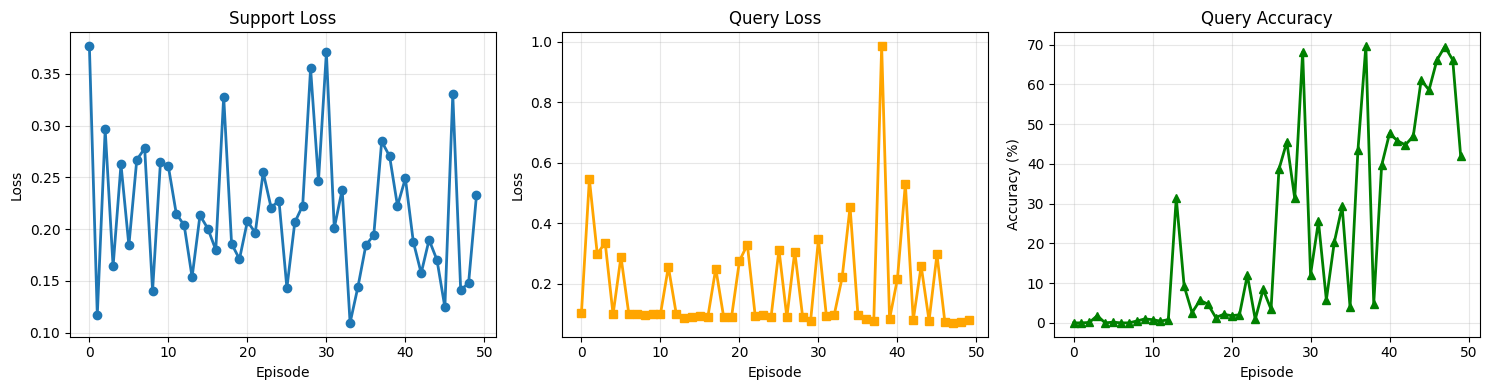

Final Accuracy: 42.01%


In [7]:
# Training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['s_loss'], marker='o', linewidth=2)
axes[0].set_title('Support Loss')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['q_loss'], marker='s', linewidth=2, color='orange')
axes[1].set_title('Query Loss')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

axes[2].plot([x*100 for x in history['q_acc']], marker='^', linewidth=2, color='green')
axes[2].set_title('Query Accuracy')
axes[2].set_ylabel('Accuracy (%)')
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlabel('Episode')

plt.tight_layout()
plt.show()

print(f"Final Accuracy: {history['q_acc'][-1]:.2%}")

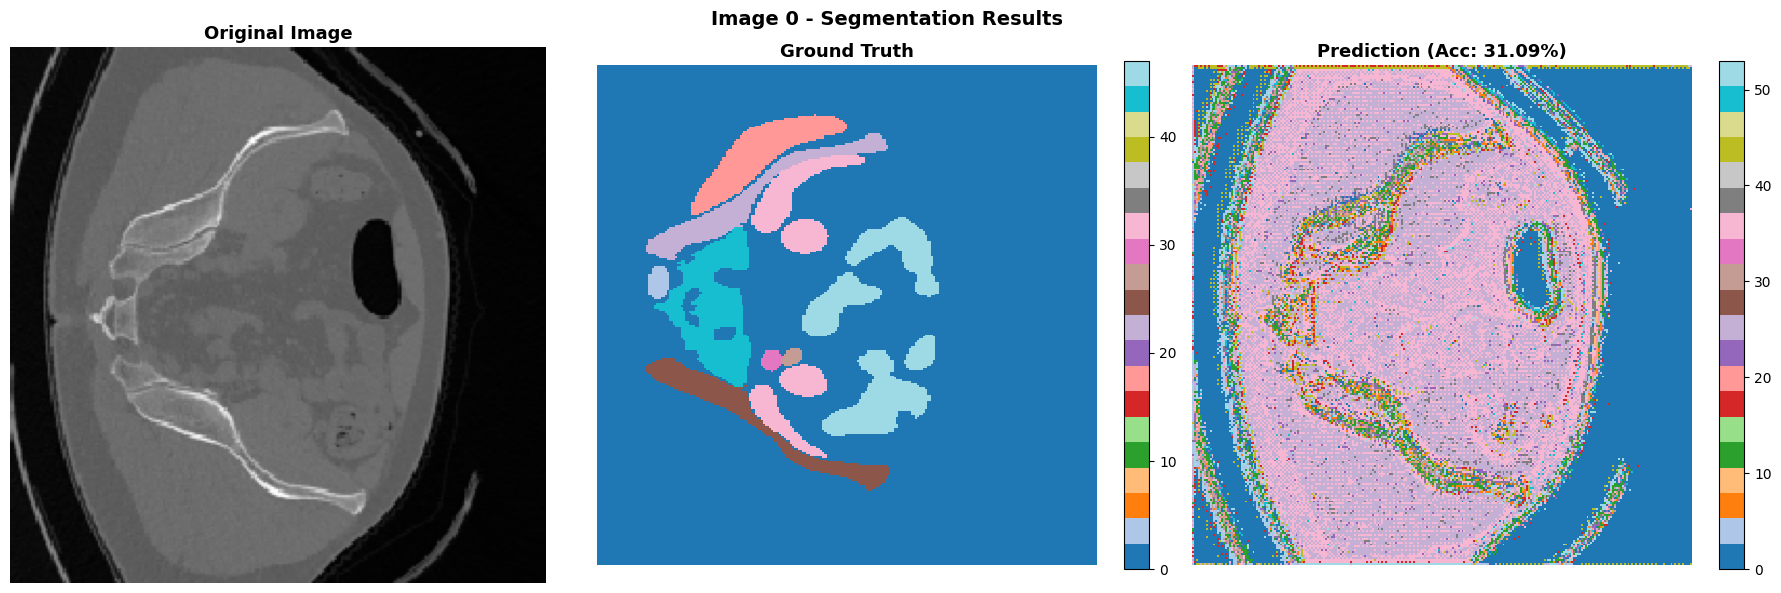


Image 0:
  GT classes: 11
  Pred classes: 40
  Pixel Accuracy: 31.09%



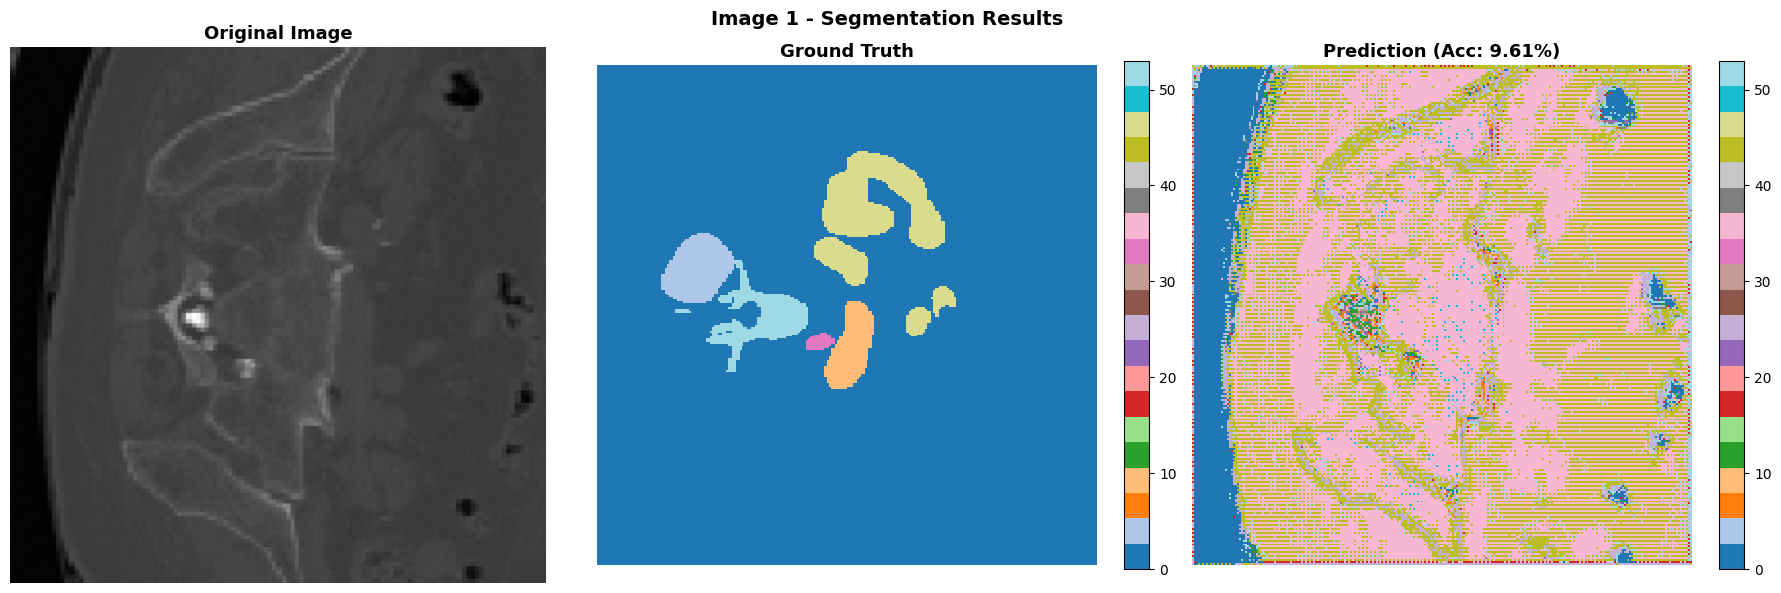


Image 1:
  GT classes: 6
  Pred classes: 31
  Pixel Accuracy: 9.61%



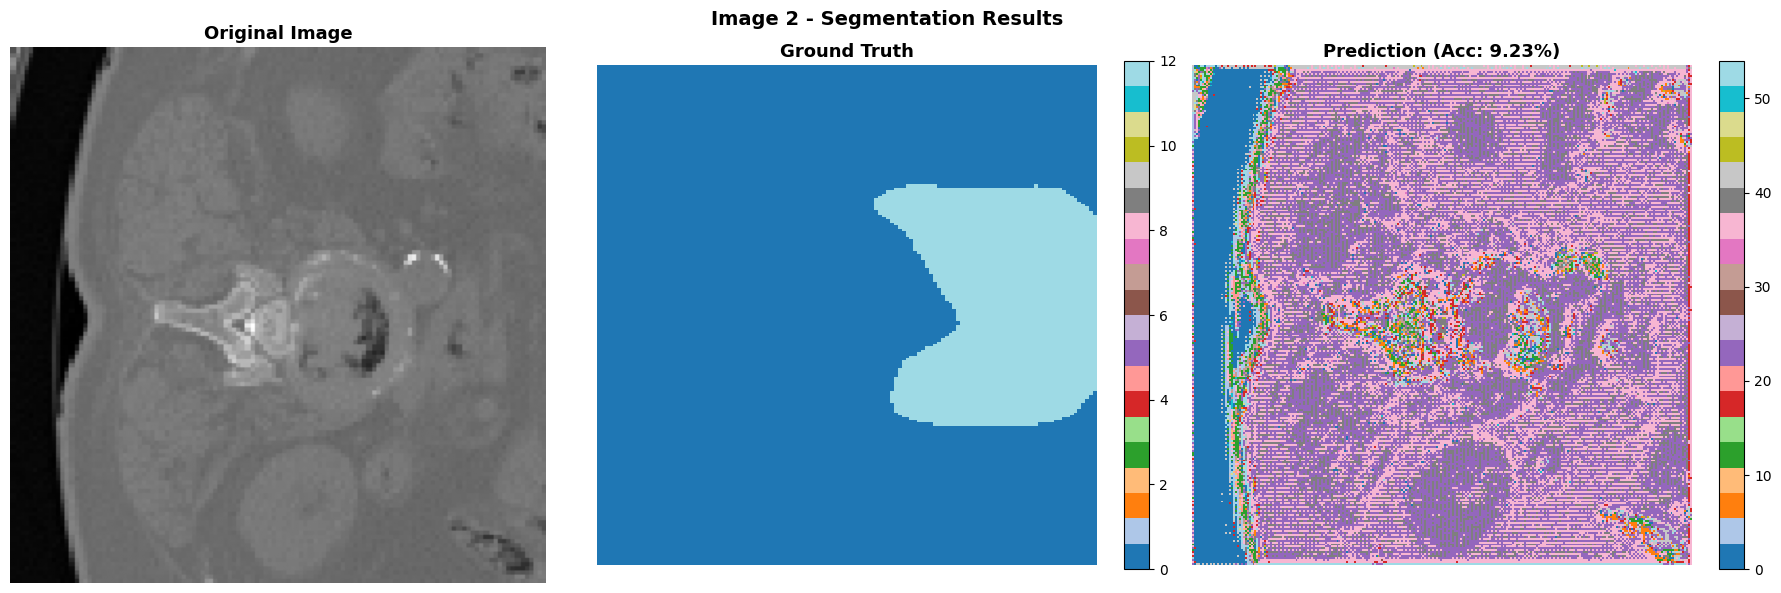


Image 2:
  GT classes: 2
  Pred classes: 37
  Pixel Accuracy: 9.23%



In [8]:
# Prediction viewer function
def show_prediction(idx):
    model.eval()
    with torch.no_grad():
        img_t = torch.tensor(images_np[idx][None, None, :, :], dtype=torch.float32).to(DEVICE)
        prior_t = torch.tensor(prior_gen.get_prior(images_np[idx])[None, :, :, :], dtype=torch.float32).to(DEVICE)
        
        logits = model(img_t, prior_t)
        pred = torch.argmax(logits, dim=1)[0].cpu().numpy()
    
    lbl = labels_2d[idx]
    acc = (pred == lbl).mean()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(images_np[idx], cmap='gray')
    axes[0].set_title('Original Image', fontsize=13, fontweight='bold')
    axes[0].axis('off')
    
    im1 = axes[1].imshow(lbl, cmap='tab20', interpolation='nearest')
    axes[1].set_title('Ground Truth', fontsize=13, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    im2 = axes[2].imshow(pred, cmap='tab20', interpolation='nearest')
    axes[2].set_title(f'Prediction (Acc: {acc:.2%})', fontsize=13, fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046)
    
    plt.suptitle(f'Image {idx} - Segmentation Results', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\nImage {idx}:")
    print(f"  GT classes: {len(np.unique(lbl))}")
    print(f"  Pred classes: {len(np.unique(pred))}")
    print(f"  Pixel Accuracy: {acc:.2%}")

# Show examples
for i in [0, 1, 2]:
    show_prediction(i)
    print()

## 🎨 Interactive Viewer - Change image index below

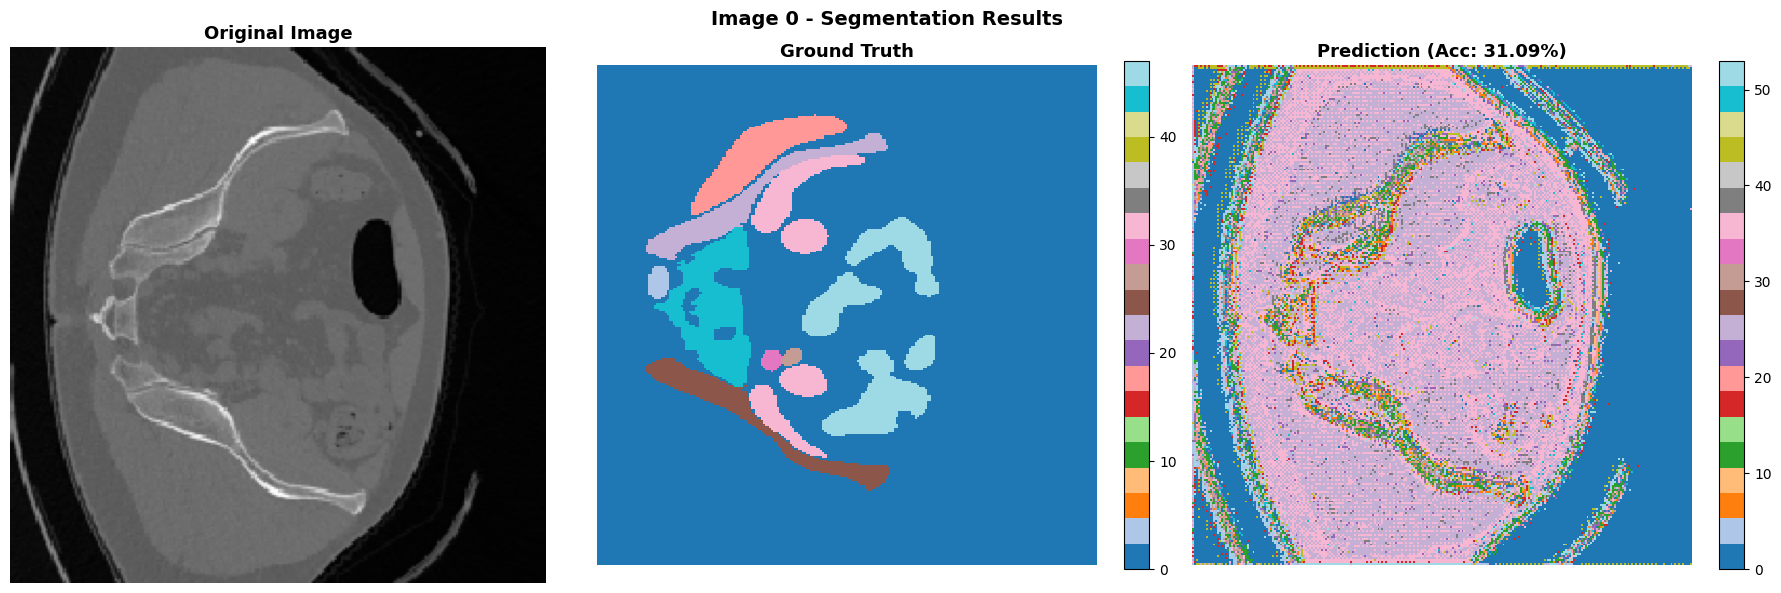


Image 0:
  GT classes: 11
  Pred classes: 40
  Pixel Accuracy: 31.09%


In [9]:
img_idx = 0  # Change to 0-7
show_prediction(img_idx)